# Transfer Function Model And Voltage-Simulation Validation

This notebook turns the PFB response investigation into a
predictive model. The goal is not just to draw the scalloping
curve; it is to predict three related quantities as a function
of signal frequency:

- coherent narrowband signal excess
- white-noise background level
- local effective SNR for a specified detector geometry

The validation data in this notebook come from
`transfer_function_experiments.py`, which runs direct setigen
voltage simulations and writes `transfer_function_results.json`.
The notebook itself is intentionally light enough to rerun
during review without regenerating every voltage simulation.


In [1]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from pfb_response_tools import PFBExperimentConfig
from pfb_transfer_model import (
    noise_alias_response,
    tone_branch_response,
)

root = Path.cwd()
with open(root / "transfer_function_results.json", encoding="utf-8") as fh:
    results = json.load(fh)

config = PFBExperimentConfig(
    sample_rate=results["config"]["sample_rate_hz"],
    num_taps=results["config"]["num_taps"],
    num_branches=results["config"]["num_branches"],
    fftlength=results["config"]["fftlength"],
    integration_factor=results["config"]["integration_factor"],
    spectra_factor=results["config"]["spectra_factor"],
)

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

results["config"]


/opt/anaconda3/envs/seti/lib/python3.14/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


{'sample_rate_hz': 64000000.0,
 'num_taps': 8,
 'num_branches': 64,
 'fftlength': 256,
 'integration_factor': 1,
 'coarse_channel_bw_hz': 1000000.0,
 'fine_channel_bw_hz': 3906.25,
 'dt_s': 0.000256,
 'spectra_factor': 32,
 'num_chans': 3,
 'target_coarse_offset': 1}

## Model

Let `h[n]` be the actual PFB prototype coefficients used by
`setigen.voltage.PolyphaseFilterbank`, `B` the number of PFB
branches, and `delta` the frequency offset from a coarse-channel
center in coarse-channel units.

A coherent tone in one branch has complex response

```text
G(delta) = sum_n h[n] exp(-2 pi i delta n / B)
R_tone(delta) = |G(delta)|^2 / |G(0)|^2
```

White voltage noise is broadband and critically decimated by the
PFB, so its baseline is an aliased power sum:

```text
R_noise(delta) = sum_m |G(delta + m)|^2 / sum_m |G(m)|^2
```

A final fine FFT adds the usual rectangular-bin response. For a
tone offset by `u` final-bin widths from a selected bin:

```text
R_fine(u) = |sin(pi u) / (F sin(pi u / F))|^2
```

The zero-drift peak-channel signal prediction is therefore

```text
R_signal = R_tone(delta) * R_fine(u)
```

For a local-noise SNR proxy, constants cancel and the useful
scale is approximately `R_signal / R_noise`, with the exact
detector aperture and integration path handled numerically.


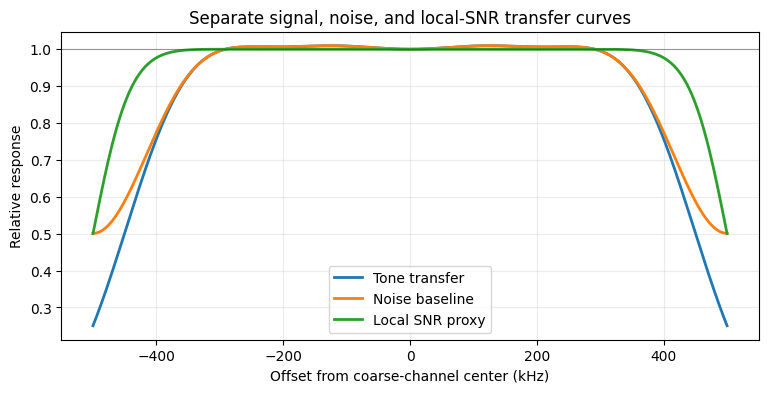

{'tone_edge_over_center': 0.25036195906041403,
 'noise_edge_over_center': 0.500723869834832,
 'local_snr_proxy_edge_over_center': 0.5000000482161916}

In [2]:
offsets = np.linspace(-0.5, 0.5, 501)
tone = tone_branch_response(config, offsets)
noise = noise_alias_response(config, offsets)
snr_proxy = tone / noise

fig, ax = plt.subplots()
ax.plot(offsets * config.chan_bw / 1e3, tone, lw=2, label="Tone transfer")
ax.plot(offsets * config.chan_bw / 1e3, noise, lw=2, label="Noise baseline")
ax.plot(offsets * config.chan_bw / 1e3, snr_proxy, lw=2, label="Local SNR proxy")
ax.axhline(1, color="0.25", lw=0.8, alpha=0.5)
ax.set_xlabel("Offset from coarse-channel center (kHz)")
ax.set_ylabel("Relative response")
ax.set_title("Separate signal, noise, and local-SNR transfer curves")
ax.legend()
display(fig)
plt.close(fig)

{
    "tone_edge_over_center": float(tone[0]),
    "noise_edge_over_center": float(noise[0]),
    "local_snr_proxy_edge_over_center": float(snr_proxy[0]),
}


The edge sensitivity is the essential result. In this
configuration, the deterministic tone peak falls to about a
quarter of its center-channel power, while the white-noise
baseline is still about half its center-channel level. The local
SNR proxy is therefore about half the center-channel value at the
exact edge.


## Exact-Bin Signal Validation

We first validate the coherent signal model in the easiest
possible case: zero drift, exact final-bin centers, signal-only
voltage simulations, no digitization or requantization. This
isolates the transfer function from stochastic noise.


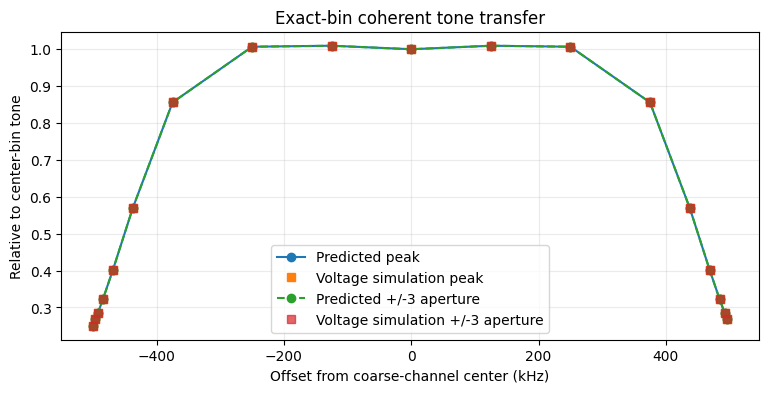

{'peak_max_abs_error': 1.950788984994567e-05,
 'aperture_max_abs_error': 1.9510550645085445e-05,
 'support_max_abs_error': 1.950788984994567e-05}

In [3]:
exact = results["exact_bin_signal_validation"]
exact_rows = exact["rows"]
offset = np.asarray([row["offset_khz"] for row in exact_rows])
actual_peak = np.asarray([row["actual_peak_rel"] for row in exact_rows])
predicted_peak = np.asarray([row["predicted_peak_rel"] for row in exact_rows])
actual_aperture = np.asarray([row["actual_aperture_rel"] for row in exact_rows])
predicted_aperture = np.asarray([row["predicted_aperture_rel"] for row in exact_rows])

fig, ax = plt.subplots()
ax.plot(offset, predicted_peak, "o-", label="Predicted peak")
ax.plot(offset, actual_peak, "s", label="Voltage simulation peak")
ax.plot(offset, predicted_aperture, "o--", label="Predicted +/-3 aperture")
ax.plot(offset, actual_aperture, "s", alpha=0.7, label="Voltage simulation +/-3 aperture")
ax.set_xlabel("Offset from coarse-channel center (kHz)")
ax.set_ylabel("Relative to center-bin tone")
ax.set_title("Exact-bin coherent tone transfer")
ax.legend()
display(fig)
plt.close(fig)

exact["metrics"]


In [4]:
[
    {
        "fine_bin": row["fine_bin"],
        "offset_khz": row["offset_khz"],
        "actual_peak_rel": row["actual_peak_rel"],
        "predicted_peak_rel": row["predicted_peak_rel"],
        "actual_minus_predicted": row["actual_peak_rel"] - row["predicted_peak_rel"],
        "actual_coarse_sum_rel": row["actual_coarse_sum_rel"],
        "predicted_coarse_sum_rel": row["predicted_coarse_sum_rel"],
    }
    for row in exact_rows
]


[{'fine_bin': 0,
  'offset_khz': -500.0,
  'actual_peak_rel': 0.25036776065826416,
  'predicted_peak_rel': 0.25036195906041403,
  'actual_minus_predicted': 5.801597850130236e-06,
  'actual_coarse_sum_rel': 0.5007372498512268,
  'predicted_coarse_sum_rel': 0.5007240989199344},
 {'fine_bin': 1,
  'offset_khz': -496.09375,
  'actual_peak_rel': 0.2675454616546631,
  'predicted_peak_rel': 0.26754929176982944,
  'actual_minus_predicted': -3.830115166358894e-06,
  'actual_coarse_sum_rel': 0.501294732093811,
  'predicted_coarse_sum_rel': 0.5013032252662207},
 {'fine_bin': 2,
  'offset_khz': -492.1875,
  'actual_peak_rel': 0.28528347611427307,
  'predicted_peak_rel': 0.2852888156426657,
  'actual_minus_predicted': -5.339528392656057e-06,
  'actual_coarse_sum_rel': 0.5030278563499451,
  'predicted_coarse_sum_rel': 0.5030370061184367},
 {'fine_bin': 4,
  'offset_khz': -484.375,
  'actual_peak_rel': 0.32229316234588623,
  'predicted_peak_rel': 0.3222993253273557,
  'actual_minus_predicted': -6.162

The signal-only validation is effectively exact at this scale:
the maximum relative error is approximately `2e-5`. This is the
core evidence that the PFB-window transfer model is the right
analytic object for coherent narrowband tone intensity.


## Off-Bin Signal Validation

Next we move the tone away from exact final-bin centers. The
model now composes the PFB branch response with the fine FFT
Dirichlet response. This tests whether the same transfer
function predicts spectral leakage, not just on-bin peaks.


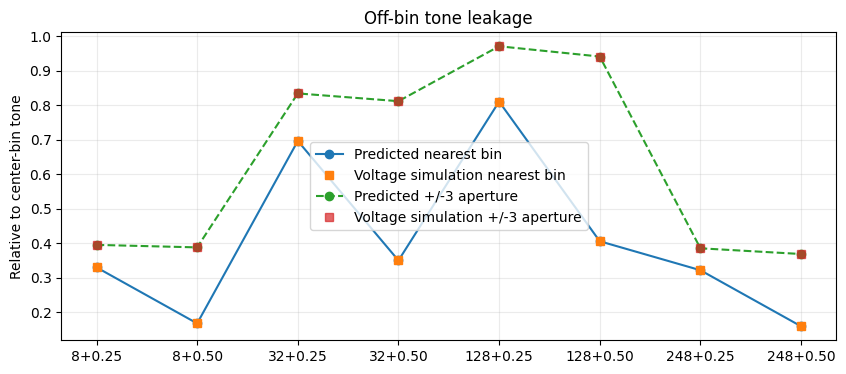

{'nearest_max_abs_error': 1.479463976200579e-05,
 'local_max_abs_error': 1.479463976200579e-05,
 'aperture_max_abs_error': 1.8694108174233115e-05}

In [5]:
offbin = results["off_bin_signal_validation"]
off_rows = offbin["rows"]
labels = [f'{row["fine_bin"]}+{row["fraction"]:.2f}' for row in off_rows]
x = np.arange(len(off_rows))

actual_nearest = np.asarray([row["actual_nearest_rel"] for row in off_rows])
predicted_nearest = np.asarray([row["predicted_nearest_rel"] for row in off_rows])
actual_aperture = np.asarray([row["actual_aperture_rel"] for row in off_rows])
predicted_aperture = np.asarray([row["predicted_aperture_rel"] for row in off_rows])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, predicted_nearest, "o-", label="Predicted nearest bin")
ax.plot(x, actual_nearest, "s", label="Voltage simulation nearest bin")
ax.plot(x, predicted_aperture, "o--", label="Predicted +/-3 aperture")
ax.plot(x, actual_aperture, "s", alpha=0.7, label="Voltage simulation +/-3 aperture")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Relative to center-bin tone")
ax.set_title("Off-bin tone leakage")
ax.legend()
display(fig)
plt.close(fig)

offbin["metrics"]


The off-bin cases also match at roughly `1e-5` to `2e-5`
relative error. That means the model can predict the full
frequency redistribution for zero-drift tones, including the
distinction between peak-bin and aperture measurements.


## Noise Validation And Observation Parameters

The noise model is stochastic, so we validate it statistically
rather than channel-by-channel. The experiment fits one scale
factor for each noise-only voltage spectrogram, then compares
the measured mean spectrum with the aliased PFB noise response.

The table also records `df` and `dt`:

```text
df = channel_bandwidth / fftlength
dt = (num_branches / sample_rate) * fftlength * integration_factor
```


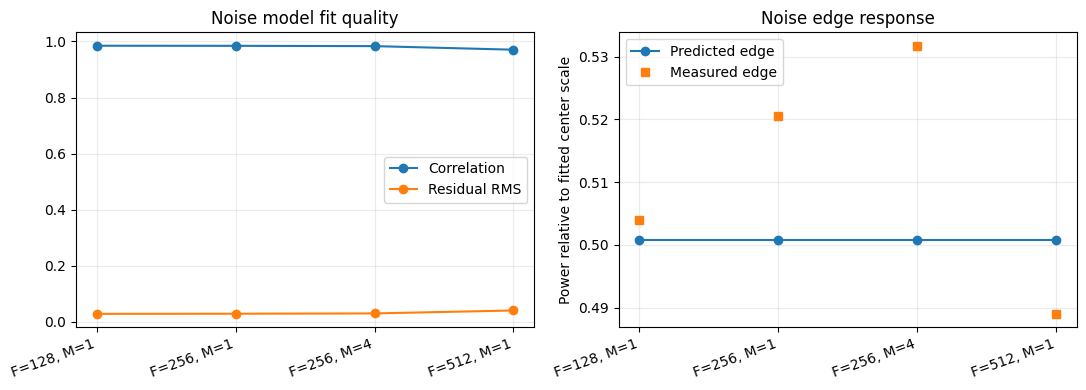

[{'fftlength': 128,
  'integration_factor': 1,
  'df_hz': 7812.5,
  'dt_s': 0.000128,
  'time_samples': 1024,
  'correlation': 0.9845782989840699,
  'relative_residual_rms': 0.028580883953966855,
  'fit_scale': 64.08361156502598,
  'measured_edge_rel': 0.5039443969726562,
  'predicted_edge_rel': 0.500723869834832,
  'measured_center_rel': 0.9522479176521301,
  'predicted_center_rel': 1.0},
 {'fftlength': 256,
  'integration_factor': 1,
  'df_hz': 3906.25,
  'dt_s': 0.000256,
  'time_samples': 1024,
  'correlation': 0.9842834898718543,
  'relative_residual_rms': 0.02897990692121318,
  'fit_scale': 63.98369130350412,
  'measured_edge_rel': 0.5205293297767639,
  'predicted_edge_rel': 0.500723869834832,
  'measured_center_rel': 0.9941763877868652,
  'predicted_center_rel': 1.0},
 {'fftlength': 256,
  'integration_factor': 4,
  'df_hz': 3906.25,
  'dt_s': 0.001024,
  'time_samples': 256,
  'correlation': 0.983192601705149,
  'relative_residual_rms': 0.030061866454103654,
  'fit_scale': 256.

In [6]:
noise_rows = results["noise_validation"]["rows"]
fftlabels = [f'F={row["fftlength"]}, M={row["integration_factor"]}' for row in noise_rows]
x = np.arange(len(noise_rows))

corr = np.asarray([row["correlation"] for row in noise_rows])
rms = np.asarray([row["relative_residual_rms"] for row in noise_rows])
edge_actual = np.asarray([row["measured_edge_rel"] for row in noise_rows])
edge_pred = np.asarray([row["predicted_edge_rel"] for row in noise_rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, corr, "o-", label="Correlation")
axes[0].plot(x, rms, "o-", label="Residual RMS")
axes[0].set_xticks(x)
axes[0].set_xticklabels(fftlabels, rotation=20, ha="right")
axes[0].set_title("Noise model fit quality")
axes[0].legend()

axes[1].plot(x, edge_pred, "o-", label="Predicted edge")
axes[1].plot(x, edge_actual, "s", label="Measured edge")
axes[1].set_xticks(x)
axes[1].set_xticklabels(fftlabels, rotation=20, ha="right")
axes[1].set_ylabel("Power relative to fitted center scale")
axes[1].set_title("Noise edge response")
axes[1].legend()
fig.tight_layout()
display(fig)
plt.close(fig)

noise_rows


The noise validation is not exact in the same way as the
signal-only case because it is a finite random realization, but
the fitted-bandpass correlations are about `0.97-0.98` and the
relative residual RMS is a few percent. Increasing the number of
spectra tightens this check; changing `fftlength` and
integration factor changes `df`, `dt`, and sample count but not
the underlying PFB transfer curve.


## Drift Validation

For drift, the current predictor is intentionally numerical and
conservative. It samples the zero-drift transfer model at each
fine-spectrum midpoint and sums the selected dedrift path. That
captures path geometry and local response variation, but it does
not yet include the exact within-FFT chirp kernel. The voltage
simulation is therefore the ground truth for identifying where
the approximation breaks.


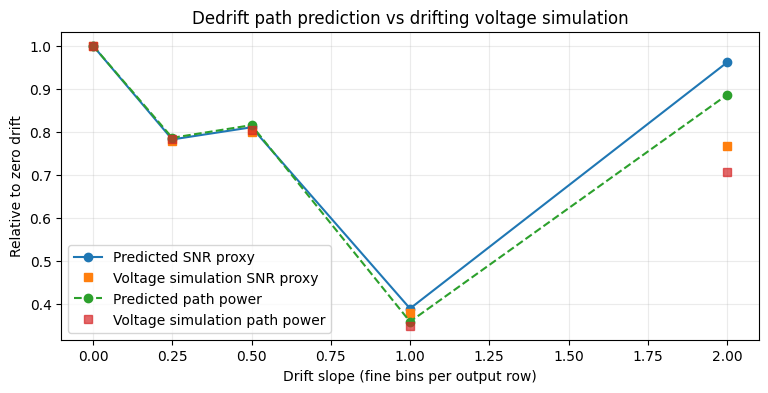

{'config': {'fftlength': 256,
  'integration_factor': 1,
  'df_hz': 3906.25,
  'dt_s': 0.000256,
  'unit_drift_hz_s': 15258789.0625},
 'rows': [{'slope_bins_per_row': 0.0,
   'drift_rate_hz_s': 0.0,
   'time_samples': 128,
   'path_start_index': 384,
   'path_stop_index': 384,
   'path_unique_channels': 1,
   'actual_path_power_rel': 1.0,
   'predicted_path_power_rel': 1.0,
   'actual_snr_proxy_rel': 1.0,
   'predicted_snr_proxy_rel': 1.0},
  {'slope_bins_per_row': 0.25,
   'drift_rate_hz_s': 3814697.265625,
   'time_samples': 128,
   'path_start_index': 384,
   'path_stop_index': 416,
   'path_unique_channels': 33,
   'actual_path_power_rel': 0.7836187194665104,
   'predicted_path_power_rel': 0.7861004253614786,
   'actual_snr_proxy_rel': 0.779844660547192,
   'predicted_snr_proxy_rel': 0.7823144140678289},
  {'slope_bins_per_row': 0.5,
   'drift_rate_hz_s': 7629394.53125,
   'time_samples': 128,
   'path_start_index': 384,
   'path_stop_index': 448,
   'path_unique_channels': 65,
   

In [7]:
drift = results["drift_validation"]
drift_rows = drift["rows"]
slope = np.asarray([row["slope_bins_per_row"] for row in drift_rows])
actual_snr = np.asarray([row["actual_snr_proxy_rel"] for row in drift_rows])
predicted_snr = np.asarray([row["predicted_snr_proxy_rel"] for row in drift_rows])
actual_power = np.asarray([row["actual_path_power_rel"] for row in drift_rows])
predicted_power = np.asarray([row["predicted_path_power_rel"] for row in drift_rows])

fig, ax = plt.subplots()
ax.plot(slope, predicted_snr, "o-", label="Predicted SNR proxy")
ax.plot(slope, actual_snr, "s", label="Voltage simulation SNR proxy")
ax.plot(slope, predicted_power, "o--", label="Predicted path power")
ax.plot(slope, actual_power, "s", alpha=0.7, label="Voltage simulation path power")
ax.set_xlabel("Drift slope (fine bins per output row)")
ax.set_ylabel("Relative to zero drift")
ax.set_title("Dedrift path prediction vs drifting voltage simulation")
ax.legend()
display(fig)
plt.close(fig)

drift


The piecewise-stationary drift model is good for modest slopes
and begins to fail at the highest tested slope. That is useful:
it tells us the next analytic term to add is the within-FFT
chirp response, i.e. replacing the static fine-FFT Dirichlet
kernel with a quadratic-phase finite sum for each FFT window.


## Working Conclusions

1. A transfer-function model exists and is numerically precise
   for zero-drift coherent tones.
2. The model must expose at least two curves:
   `tone_response` for coherent signal excess and
   `noise_response` for stochastic background.
3. The detector geometry matters. Peak-bin, local aperture,
   cross-coarse sum, and dedrifted path measurements have
   different response curves.
4. Observation parameters enter through `df`, `dt`, number of
   integrations, polarization count, and the detector path. For
   fixed observation time, integration factor trades per-pixel
   SNR against number of path samples; drift can break the
   simple cancellation.
5. Drifting signals should be handled by a numerical path model
   first, then upgraded with an exact chirp kernel and validated
   against voltage simulations.
